In [1]:
# imports 
import cv2 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from pathlib import Path
from collections import defaultdict, deque
import shutil 
#from dataset import create_dataloaders
import hashlib
from torchvision import datasets, transforms

In [2]:
# Get the list of images for each letter
path = os.path.abspath(".") 
parent_path = Path(path).parents[1]

signs = os.listdir(parent_path / "data" / "asl_dataset" / "asl_alphabet_train")[1:]
total = 0

# Get the size of training dataset 
for letters in signs:
    letter_images = os.listdir(parent_path / "data" / "asl_dataset" / "asl_alphabet_train" / f"{letters}")
    total += len(letter_images)

print(f"Total Dataset Size: {total}")




Total Dataset Size: 87000


In [3]:
num_letter_images = {}
# Get the number of images for each letter 
for letter in signs:
    letter_images = len(os.listdir(parent_path / "data" / "asl_dataset" / "asl_alphabet_train" / f"{letters}"))
    num_letter_images[letter] = letter_images 

print("Number of images for each letter:")
for key, value in num_letter_images.items():
    print(f"{key}: {value}")

Number of images for each letter:
R: 3000
U: 3000
I: 3000
N: 3000
G: 3000
Z: 3000
T: 3000
S: 3000
A: 3000
F: 3000
O: 3000
H: 3000
del: 3000
nothing: 3000
space: 3000
M: 3000
J: 3000
C: 3000
D: 3000
V: 3000
Q: 3000
X: 3000
E: 3000
B: 3000
K: 3000
L: 3000
Y: 3000
P: 3000
W: 3000


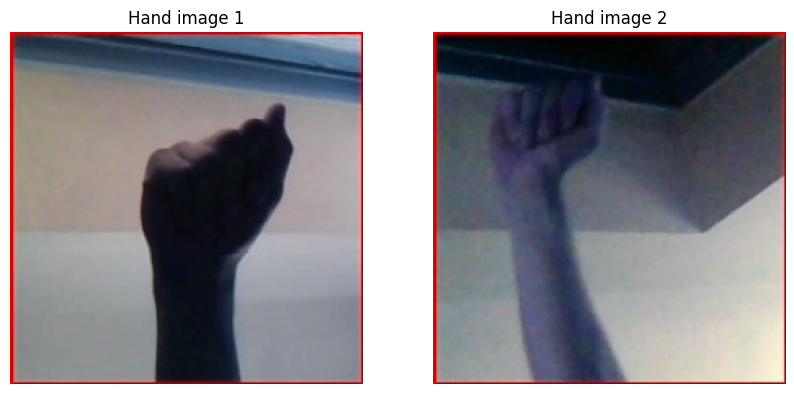

In [4]:
# Load random images and compare them 
path = parent_path / "data" / "asl_dataset" / "asl_alphabet_train" / "A"
letter_a_images = os.listdir(parent_path / "data" / "asl_dataset" / "asl_alphabet_train" / "A")

img1 = cv2.imread(Path(path) / letter_a_images[0])
img2 = cv2.imread(Path(path) / letter_a_images[1])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Hand image 1")
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Hand image 2")
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.show()




* Some images are a little dark, although you can still see the hand, it would help to make sure there aren't images that are so dark where it is too hard to see as this would only be noise when it comes time for training.

In [5]:
path = os.path.abspath(".") 
parent_path = Path(path).parents[1]

image_path = parent_path / "data" / "asl_dataset" / "asl_alphabet_train"

grayscale_intensity_img = defaultdict()

for letter_folder in image_path.iterdir():
    if not letter_folder.is_dir():
        continue 

    letter = letter_folder.name

    for letter_image in letter_folder.iterdir():
        img = cv2.imread(str(letter_image), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue 
            
        brightness = float(img.mean())

        grayscale_intensity_img[letter_image] = {
            "label": letter, 
            "brightness": brightness  
        }

In [6]:
brightness_values = [value["brightness"] for value in grayscale_intensity_img.values()]

# Get the mean and standard deviation of the brightness values
mean = np.array(brightness_values).mean()
std = np.array(brightness_values).std()

# Set threshold value 
k = 2
threshold = mean - (k * std)

In [ ]:
# Place a folder insice asl_dataset folder and add all candidate images inside 
Path(parent_path / "data" / "asl_dataset" / "potential_dark_candidates").mkdir(parents=True, exist_ok=True)

destination = Path(parent_path / "data" / "asl_dataset" / "potential_dark_candidates")
for img_path, data in grayscale_intensity_img.items():
    if data["brightness"] < threshold:
        # Place image inside folder 
        shutil.copy(img_path, destination)
        



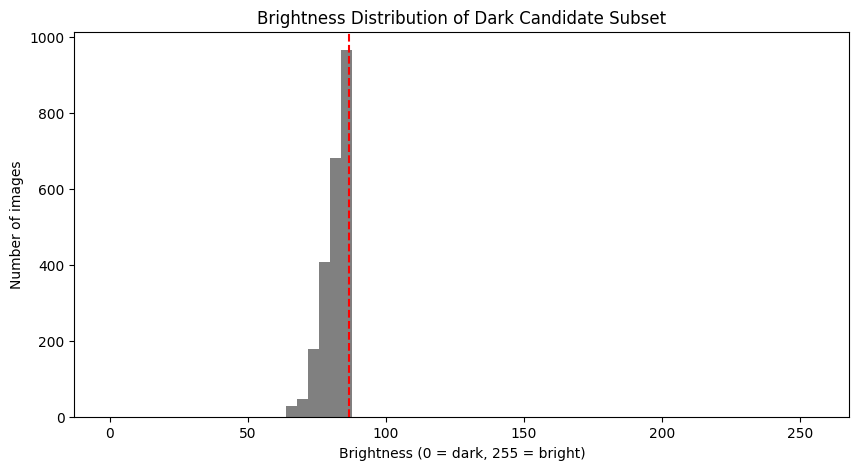

In [7]:
# Get the size of the potential_dark_candidates folder
images = Path(parent_path / "data" / "asl_dataset" / "potential_dark_candidates")
brightness_arr = deque()

for img_path in images.iterdir():
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    brightness_arr.append(float(img.mean()))


# Convert queue to numpy 
brightness_arr = np.array(brightness_arr)
n = 64

# Plot the histogram 
plt.figure(figsize=(10, 5))
plt.hist(brightness_arr, bins=n, range=(0, 255), color="gray")
plt.title("Brightness Distribution of Dark Candidate Subset")
plt.xlabel("Brightness (0 = dark, 255 = bright)")
plt.ylabel("Number of images")
plt.axvline(threshold, color="red", linestyle="--", label="Dark threshold")
plt.show()




In [3]:
train_path = parent_path / "data" / "asl_dataset" / "asl_alphabet_train"

data = []

for label_folder in train_path.iterdir():
    if str(label_folder).endswith('.DS_Store'):
        continue 

    label = label_folder.name 

    for images in label_folder.iterdir():
        data.append((str(images), label))
    

In [4]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data,
    test_size=0.20,
    stratify=[label for _, label in data],
    random_state=42
)

test_data, val_data = train_test_split(
    temp_data,
    test_size=0.5, 
    stratify=[label for _, label in temp_data],
    random_state=42
)

In [5]:
output_path = parent_path / "data" / "processed"

def save_split(split_data, split_name):
    for image, label in split_data:
        img_path = Path(image)

        save_path = output_path / split_name / label 
        save_path.mkdir(parents=True, exist_ok=True)

        shutil.copy(img_path, save_path / img_path.name)

save_split(train_data, "train")
save_split(val_data, "val")
save_split(test_data, "test")

In [6]:
def get_split_size(path):
    total = 0
    for letter_path in path.iterdir():
        total += len(os.listdir(letter_path))
    return total
    
    
# Ensure the lengths of train and validation split are correct 
train_path = parent_path / "data" / "processed" / "train" 
val_path = parent_path / "data" / "processed" / "val"
test_path = parent_path / "data" / "processed" / "test"

print(f"Train split size: {get_split_size(train_path)}")
print(f"Validation split size: {get_split_size(val_path)}")
print(f"Test split size {get_split_size(test_path)}")

Train split size: 69600
Validation split size: 8700
Test split size 8700


In [7]:
# Ensure balance for each letter in train data 
path = parent_path / "data" / "processed" / "train" 

for letter_folder in path.iterdir():
    letter = letter_folder.name 
    train_examples = len(os.listdir(letter_folder))

    print(f"{letter}: {train_examples}")

R: 2400
U: 2400
I: 2400
N: 2400
G: 2400
Z: 2400
T: 2400
S: 2400
A: 2400
F: 2400
O: 2400
H: 2400
del: 2400
nothing: 2400
space: 2400
M: 2400
J: 2400
C: 2400
D: 2400
V: 2400
Q: 2400
X: 2400
E: 2400
B: 2400
K: 2400
L: 2400
Y: 2400
P: 2400
W: 2400


In [8]:
# Ensure balance for each letter in validation data 
path = parent_path / "data" / "processed" / "val" 

for letter_folder in path.iterdir():
    letter = letter_folder.name 
    val_examples = len(os.listdir(letter_folder))

    print(f"{letter}: {val_examples}")

R: 300
U: 300
I: 300
N: 300
G: 300
Z: 300
T: 300
S: 300
A: 300
F: 300
O: 300
H: 300
del: 300
nothing: 300
space: 300
M: 300
J: 300
C: 300
D: 300
V: 300
Q: 300
X: 300
E: 300
B: 300
K: 300
L: 300
Y: 300
P: 300
W: 300


In [9]:
# Ensure the balance for each data in the test set 
path = parent_path / "data" / "processed" / "test" 

for letter_folder in path.iterdir():
    letter = letter_folder.name 
    test_examples = len(os.listdir(letter_folder))

    print(f"{letter}: {test_examples}")


R: 300
U: 300
I: 300
N: 300
G: 300
Z: 300
T: 300
S: 300
A: 300
F: 300
O: 300
H: 300
del: 300
nothing: 300
space: 300
M: 300
J: 300
C: 300
D: 300
V: 300
Q: 300
X: 300
E: 300
B: 300
K: 300
L: 300
Y: 300
P: 300
W: 300


In [10]:
train_dir = "/Users/rohan/Desktop/Python-Projects/asl-video-translator/data/processed/train"
val_dir = "/Users/rohan/Desktop/Python-Projects/asl-video-translator/data/processed/val"
test_dir = "/Users/rohan/Desktop/Python-Projects/asl-video-translator/data/processed/test"

# Load the training and validation data and verify there is no overlap.
data_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
val_data = datasets.ImageFolder(root=val_dir, transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

train_paths = [path for path, _ in train_data.samples]
val_paths = [path for path, _ in val_data.samples]
test_paths = [path for path, _ in test_data.samples]

train_files = set(train_paths)
val_files = set(val_paths)
test_files = set(test_paths)

overlap_path_train_val = train_files & val_files
overlap_path_train_test = train_files & test_files 
overlap_path_val_test = test_files & val_files

print(f"Overlapping file paths between train and val: {len(overlap_path_train_val)}")
print(f"Overlapping file paths between train and test: {len(overlap_path_train_test)}")
print(f"Overlapping file paths between val and test: {len(overlap_path_val_test)}")

# Verify identical image data is not present across train and validation splits.
def hash_image_file(path):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

train_hashes = {hash_image_file(path) for path in train_paths}
val_hashes = {hash_image_file(path) for path in val_paths}
test_hashes = {hash_image_file(path) for path in test_paths}

overlap_hashes_train_val = train_hashes & val_hashes
overlap_hashes_train_test = train_hashes & test_hashes
overlap_hashes_test_val = test_hashes & val_hashes 

print(f"Overlapping image hashes between train and val: {len(overlap_hashes_train_val)}")
print(f"Overlapping image hashes between train and test: {len(overlap_hashes_train_test)}")
print(f"Overlapping image hashes between test and val: {len(overlap_hashes_test_val)}")

Overlapping file paths between train and val: 0
Overlapping file paths between train and test: 0
Overlapping file paths between val and test: 0
Overlapping image hashes between train and val: 0
Overlapping image hashes between train and test: 0
Overlapping image hashes between test and val: 0
